# Cyberbullying Detection using Bidirectional LSTM
**Dataset:** Suspicious Communication on Social Platforms  
**Task:** Binary classification — `1` = Bullying, `0` = Not Bullying  
**Architecture:** Embedding → SpatialDropout → BiLSTM → Dense → Sigmoid

## 1. Install Dependencies

In [ ]:
import sys
print(f"Python version: {sys.version}")

import subprocess
packages = ["tensorflow", "scikit-learn", "matplotlib", "seaborn", "pandas", "numpy"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("All packages installed.")

## 2. Imports

In [6]:
import os
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/home/samidha_bhoir/miniconda3/envs/ml/lib"

In [1]:
import tensorflow as tf
# print("JIT:", tf.config.optimizer.get_jit())

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional,
    Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version : 2.19.0
NumPy version      : 2.0.2


In [11]:
from google.colab import files
uploaded = files.upload()  # manually upload the CSV here

KeyboardInterrupt: 

## 3. Load and Explore Data

In [9]:
df = pd.read_csv('Suspicious Communication on Social Platforms.csv')
df.columns = df.columns.str.strip()
df['comments'] = df['comments'].astype(str).str.strip()
df['tagging']  = df['tagging'].astype(str).str.strip().astype(int)

print(f"Dataset shape : {df.shape}")
print(f"\nLabel distribution:")
print(df['tagging'].value_counts().rename(index={0: 'Not Bullying (0)', 1: 'Bullying (1)'}))
print(f"\nNull values   : {df.isnull().sum().sum()}")
df.sample(5, random_state=SEED)

FileNotFoundError: [Errno 2] No such file or directory: 'Suspicious Communication on Social Platforms.csv'

NameError: name 'df' is not defined

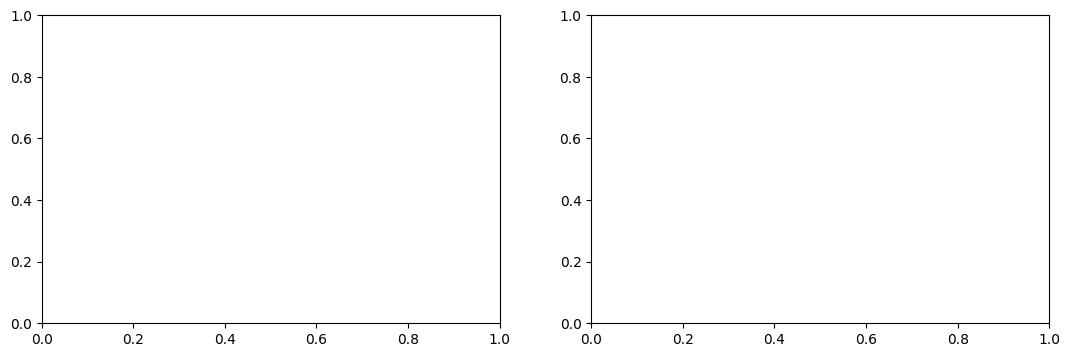

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

label_counts = df['tagging'].value_counts().sort_index()
bars = axes[0].bar(['Not Bullying (0)', 'Bullying (1)'],
                   label_counts.values,
                   color=['steelblue', 'tomato'], edgecolor='black')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 str(val), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

df['text_len'] = df['comments'].apply(lambda x: len(x.split()))
axes[1].hist(df[df['tagging']==0]['text_len'], bins=50, alpha=0.6,
             label='Not Bullying', color='steelblue')
axes[1].hist(df[df['tagging']==1]['text_len'], bins=50, alpha=0.6,
             label='Bullying', color='tomato')
axes[1].set_title('Token Length Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()
print(df['text_len'].describe().round(1))

## 4. Text Preprocessing

In [4]:
def clean_text(text: str) -> str:
    """Normalise and clean a raw comment string."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)   # URLs
    text = re.sub(r'@\w+', '', text)                 # @mentions
    text = re.sub(r'#\w+', '', text)                 # #hashtags
    text = re.sub(r'[^a-z\s]', '', text)            # non-alpha
    text = re.sub(r'\s+', ' ', text).strip()        # whitespace
    return text

df['clean_text'] = df['comments'].apply(clean_text)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

print(f"Rows after cleaning : {len(df)}")
print("\nBefore / After examples:")
for _, row in df.sample(3, random_state=SEED).iterrows():
    print(f"  ORIGINAL : {row['comments'][:90]}")
    print(f"  CLEANED  : {row['clean_text'][:90]}\n")

NameError: name 'df' is not defined

## 5. Train / Test Split

In [16]:
X = df['clean_text'].values
y = df['tagging'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Train : {len(X_train)} samples  (0={np.sum(y_train==0)}  1={np.sum(y_train==1)})")
print(f"Test  : {len(X_test)}  samples  (0={np.sum(y_test ==0)}  1={np.sum(y_test ==1)})")

Train : 15924 samples  (0=9686  1=6238)
Test  : 3981  samples  (0=2422  1=1559)


## 6. Tokenisation and Sequence Padding

In [17]:
MAX_VOCAB_SIZE = 15000
MAX_SEQ_LEN    = 100

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token='<OOV>',
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=MAX_SEQ_LEN, padding='post', truncating='post'
)
X_test_pad  = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_SEQ_LEN, padding='post', truncating='post'
)

VOCAB_SIZE = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)

print(f"Vocab size (capped) : {VOCAB_SIZE}")
print(f"Unique tokens       : {len(tokenizer.word_index)}")
print(f"X_train_pad shape   : {X_train_pad.shape}")
print(f"X_test_pad  shape   : {X_test_pad.shape}")

Vocab size (capped) : 15000
Unique tokens       : 15848
X_train_pad shape   : (15924, 100)
X_test_pad  shape   : (3981, 100)


## 7. Model Architecture — Bidirectional LSTM

In [18]:
EMBEDDING_DIM = 128
LSTM_UNITS    = 128

model = Sequential([
    # 1. Word Embedding — learns dense vector per token
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQ_LEN,
        name='embedding'
    ),
    # 2. SpatialDropout — drops entire word vectors (better than regular dropout here)
    SpatialDropout1D(0.3, name='spatial_dropout'),
    # 3. Bidirectional LSTM — reads sequence in both directions
    Bidirectional(
        LSTM(LSTM_UNITS, dropout=0.2),
        name='bi_lstm'
    ),
    # 4. Dense hidden layer
    Dense(64, activation='relu', name='dense_hidden'),
    Dropout(0.4, name='dropout'),
    # 5. Sigmoid output for binary classification
    Dense(1, activation='sigmoid', name='output')
], name='BullyDetector_BiLSTM')

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

model.summary()

Model: "BullyDetector_BiLSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 128)          1920000   
                                                                 
 spatial_dropout (SpatialDr  (None, 100, 128)          0         
 opout1D)                                                        
                                                                 
 bi_lstm (Bidirectional)     (None, 256)               263168    
                                                                 
 dense_hidden (Dense)        (None, 64)                16448     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 output (Dense)              (None, 1)                 65        
                                              

In [19]:
print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 8. Training

In [20]:
EPOCHS     = 15
BATCH_SIZE = 64

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=3,
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        filepath='lstm_bully_model.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

history = model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15


2026-03-27 17:42:38.247200: W tensorflow/compiler/xla/service/gpu/llvm_gpu_backend/gpu_backend_lib.cc:273] libdevice is required by this HLO module but was not found at ./libdevice.10.bc
2026-03-27 17:42:38.248356: W tensorflow/core/framework/op_kernel.cc:1828] OP_REQUIRES failed at xla_ops.cc:503 : INTERNAL: libdevice not found at ./libdevice.10.bc
2026-03-27 17:42:38.266857: W tensorflow/compiler/xla/service/gpu/llvm_gpu_backend/gpu_backend_lib.cc:273] libdevice is required by this HLO module but was not found at ./libdevice.10.bc
2026-03-27 17:42:38.267922: W tensorflow/core/framework/op_kernel.cc:1828] OP_REQUIRES failed at xla_ops.cc:503 : INTERNAL: libdevice not found at ./libdevice.10.bc
2026-03-27 17:42:38.286146: W tensorflow/compiler/xla/service/gpu/llvm_gpu_backend/gpu_backend_lib.cc:273] libdevice is required by this HLO module but was not found at ./libdevice.10.bc
2026-03-27 17:42:38.287240: W tensorflow/core/framework/op_kernel.cc:1828] OP_REQUIRES failed at xla_ops.cc:5

InternalError: Graph execution error:

Detected at node 'Adam/StatefulPartitionedCall_10' defined at (most recent call last):
    File "/home/samidha_bhoir/miniconda3/envs/ml/lib/python3.10/runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/home/samidha_bhoir/miniconda3/envs/ml/lib/python3.10/runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "/home/samidha_bhoir/miniconda3/envs/ml/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "/home/samidha_bhoir/miniconda3/envs/ml/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
      app.start()
    File "/home/samidha_bhoir/miniconda3/envs/ml/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 736, in start
      self.io_loop.start()
    File "/home/samidha_bhoir/miniconda3/envs/ml/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 211, in start

## 9. Training History Plots

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train',      color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='tomato', linestyle='--')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train',      color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation', color='tomato', linestyle='--')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_history.png")

## 10. Evaluation on Test Set

In [ ]:
y_pred_prob = model.predict(X_test_pad, batch_size=128, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"{'='*44}")
print(f"  Test Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  ROC-AUC Score  : {auc:.4f}")
print(f"{'='*44}\n")
print(classification_report(y_test, y_pred,
      target_names=['Not Bullying', 'Bullying']))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Bullying', 'Bullying'],
            yticklabels=['Not Bullying', 'Bullying'],
            linewidths=0.5)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=1, linestyle='--',
         label='Random Classifier')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curve.png")

## 11. Save Model and Tokenizer

In [ ]:
model.save('lstm_bully_model.keras')
print("Model saved     -> lstm_bully_model.keras")

with open('lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved -> lstm_tokenizer.pkl")

with open('lstm_meta.pkl', 'wb') as f:
    pickle.dump({'MAX_SEQ_LEN': MAX_SEQ_LEN, 'MAX_VOCAB_SIZE': MAX_VOCAB_SIZE}, f)
print("Metadata saved  -> lstm_meta.pkl")

## 12. Prediction Function

In [ ]:
def predict_bullying(text: str, threshold: float = 0.5) -> dict:
    """
    Predict whether a sentence is bullying.

    Parameters
    ----------
    text      : raw input sentence
    threshold : decision boundary (default 0.5)

    Returns
    -------
    dict with keys: text, cleaned, label, confidence
    """
    cleaned = clean_text(text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
    prob    = float(model.predict(padded, verbose=0)[0][0])
    label   = 'Bullying' if prob >= threshold else 'Not Bullying'
    return {
        'text'      : text,
        'cleaned'   : cleaned,
        'label'     : label,
        'confidence': f"{prob:.2%}"
    }


# --- Demo predictions ---
test_sentences = [
    "You are such a loser, nobody likes you!",
    "Have a wonderful day, hope everything goes well for you!",
    "I hate you, you should just disappear forever.",
    "Let's catch up for coffee sometime this week.",
    "You're so ugly and stupid, go kill yourself.",
    "Great job on the presentation today, really impressive!"
]

print(f"{'Text':<45} {'Label':<16} {'Confidence'}")
print('-' * 72)
for s in test_sentences:
    r = predict_bullying(s)
    print(f"{r['text'][:43]:<45} {r['label']:<16} {r['confidence']}")

In [ ]:
# Interactive single-sentence prediction
user_input = input("Enter a sentence to classify: ")
r = predict_bullying(user_input)
print(f"\nInput      : {r['text']}")
print(f"Cleaned    : {r['cleaned']}")
print(f"Prediction : {r['label']}")
print(f"Confidence : {r['confidence']}")